## Les membres du groupe:
### Lassana DEMBE
### Ibrahim DOUMBIA

### Phase d'importation des bibliothèques

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [108]:
#Les chemins
path1= 'C:/Users/MSIEA/books.csv'
path2= 'C:/Users/MSIEA/users.csv'
path3= 'C:/Users/MSIEA/ratings.csv'

#Chargements des jeux de données
books = pd.read_csv(path1)
users = pd.read_csv(path2)
ratings = pd.read_csv(path3)

C:\Users\MSIEA\AppData\Local\Temp\ipykernel_15936\2965111220.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(path1)


### Affichage des jeux de données

In [109]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [110]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [111]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


## Phase de prétraitement

#### Vérifications des lignes manquantes pour le jeu de données books

In [112]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            1
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [113]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [114]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

#### La suppression des lignes contenants des valeurs manquantes

In [115]:
users.dropna(inplace=True)

In [116]:
books.dropna(inplace=True)

In [117]:
users.head()

,User-ID,Location,Age
1,2,"stockton, california, usa",18.0
3,4,"porto, v.n.gaia, portugal",17.0
5,6,"santa monica, california, usa",61.0
9,10,"albacete, wisconsin, spain",26.0
10,11,"melbourne, victoria, australia",14.0


In [118]:
books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


#### Vérification à nouveau

In [119]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

In [120]:
users.isnull().sum()

User-ID     0
Location    0
Age         0
dtype: int64

#### Vérifications des lignes dupliquées

In [121]:
books.duplicated().sum()

0

In [122]:
ratings.duplicated().sum()

0

In [123]:
users.duplicated().sum()

0

#### Suppression des trois dernières colonnes de books

In [124]:
#Visualisation des colonnes avant la suppréssion
books.columns

Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')

In [125]:
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]

In [126]:
#Visualisation des colonnes après la suppréssion
books.columns

Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication',
       'Publisher'],
      dtype='object')

In [127]:
books.rename(columns={'Book-Author':'Auteur', 'Book-Title':'Titre' },inplace=True)

C:\Users\MSIEA\AppData\Local\Temp\ipykernel_15936\472501777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books.rename(columns={'Book-Author':'Auteur', 'Book-Title':'Titre' },inplace=True)


In [128]:
ratings.rename(columns={'Book-Rating':'Note' },inplace=True)

In [129]:
books

,ISBN,Titre,Auteur,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company
...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm)
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press


In [130]:
ratings

,User-ID,ISBN,Note
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


#### Vérification des informations sur les données avec la méthodes info()

In [131]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 271354 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271354 non-null  object
 1   Titre                271354 non-null  object
 2   Auteur               271354 non-null  object
 3   Year-Of-Publication  271354 non-null  object
 4   Publisher            271354 non-null  object
dtypes: object(5)
memory usage: 12.4+ MB


In [132]:
users.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 168096 entries, 1 to 278854
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   168096 non-null  int64  
 1   Location  168096 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.1+ MB


In [133]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   User-ID  1149780 non-null  int64 
 1   ISBN     1149780 non-null  object
 2   Note     1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


#### La description des données à l'aide de la méthode describe()

In [134]:
books.describe()

,ISBN,Titre,Auteur,Year-Of-Publication,Publisher
count,271354,271354,271354,271354,271354
unique,271354,242130,102020,200,16803
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin
freq,1,27,632,13902,7535


In [135]:
users.describe()

,User-ID,Age
count,168096.000000,168096.000000
mean,139394.611865,34.751434
std,80561.659564,14.428097
min,2.000000,0.000000
25%,69914.750000,24.000000
50%,139363.500000,32.000000
75%,209162.500000,44.000000
max,278855.000000,244.000000


In [136]:
ratings.describe()

,User-ID,Note
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


In [137]:
# effectuer une fusion (ou jointure) entre les jeux de données ratings et books en utilisant la colonne 'ISBN' comme clé de jointure
evaluation_livre = ratings.merge(books,on='ISBN')

In [138]:
evaluation_livre.rename(columns={'Book-Rating':'Note'},inplace=True)

In [139]:
evaluation_livre

,User-ID,ISBN,Note,Titre,Auteur,Year-Of-Publication,Publisher
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
1,2313,034545104X,5,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
2,6543,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
3,8680,034545104X,5,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
4,10314,034545104X,9,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
...,...,...,...,...,...,...,...
1031124,276688,0517145553,0,Mostly Harmless,Douglas Adams,1995,Random House Value Pub
1031125,276688,1575660792,7,Gray Matter,Shirley Kennett,1996,Kensington Publishing Corporation
1031126,276690,0590907301,0,Triplet Trouble and the Class Trip (Triplet Tr...,Debbie Dadey,1997,Apple
1031127,276704,0679752714,0,A Desert of Pure Feeling (Vintage Contemporaries),Judith Freeman,1997,Vintage Books USA


In [152]:
note_evaluation = evaluation_livre.groupby('Titre').count()['Note'].reset_index() # Selection de deux colonnes 
note_evaluation.rename(columns={'Book-Title':'Titre' },inplace=True)# Renomme la colonne Book-Rating en Note et Book-Title en Titre
note_evaluation

,Titre,Note
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241061,Ã?Â?lpiraten.,2
241062,Ã?Â?rger mit Produkt X. Roman.,4
241063,Ã?Â?sterlich leben.,1
241064,Ã?Â?stlich der Berge.,3


In [153]:
moyenne_evaluation = evaluation_livre.groupby('Titre').mean()['Note'].reset_index()#Selection de deux colonnes et la colonne Book-Rating contient la moyenne des notes d'évaluation pour chaque livre 
moyenne_evaluation.rename(columns={'Note':'Note-Moyenne',  },inplace=True)# Renomme la colonne Book-Rating en Note-Moyenne et Book-Title en Titre
moyenne_evaluation

,Titre,Note-Moyenne
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241061,Ã?Â?lpiraten.,0.000000
241062,Ã?Â?rger mit Produkt X. Roman.,5.250000
241063,Ã?Â?sterlich leben.,7.000000
241064,Ã?Â?stlich der Berge.,2.666667


In [155]:
#effectuer une fusion (ou jointure) entre les données de num_rating et avg_rating en utilisant la colonne 'Book-Title' comme clé de jointure.
livre_evalue = note_evaluation.merge(moyenne_evaluation,on='Titre')
livre_evalue

,Titre,Note,Note-Moyenne
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241061,Ã?Â?lpiraten.,2,0.000000
241062,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241063,Ã?Â?sterlich leben.,1,7.000000
241064,Ã?Â?stlich der Berge.,3,2.666667


In [141]:
books

,ISBN,Titre,Auteur,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company
...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm)
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press


In [156]:
livre_evalue= livre_evalue[livre_evalue['Note']>=250].sort_values('Note-Moyenne',ascending=False).head(50)#On sélection uniquement les lignes ou la Note atteint 250 et on trie par ordre décroissant suivant la Note-Moyenne

In [157]:
livre_evalue = livre_evalue.merge(books,on='Titre').drop_duplicates('Titre')[['Titre','Auteur','Note','Note-Moyenne']]#On effectue une jointure entre livre_evalue et books en sélectionnant certaines colonnes

In [158]:
livre_evalue

,Titre,Auteur,Note,Note-Moyenne
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,260,4.880769
39,To Kill a Mockingbird,Harper Lee,510,4.700000


In [194]:
users

,User-ID,Location,Age
1,2,"stockton, california, usa",18.0
3,4,"porto, v.n.gaia, portugal",17.0
5,6,"santa monica, california, usa",61.0
9,10,"albacete, wisconsin, spain",26.0
10,11,"melbourne, victoria, australia",14.0
...,...,...,...
278848,278849,"georgetown, ontario, canada",23.0
278850,278851,"dallas, texas, usa",33.0
278851,278852,"brisbane, queensland, australia",32.0
278852,278853,"stranraer, n/a, united kingdom",17.0


## Analyse exploratoire

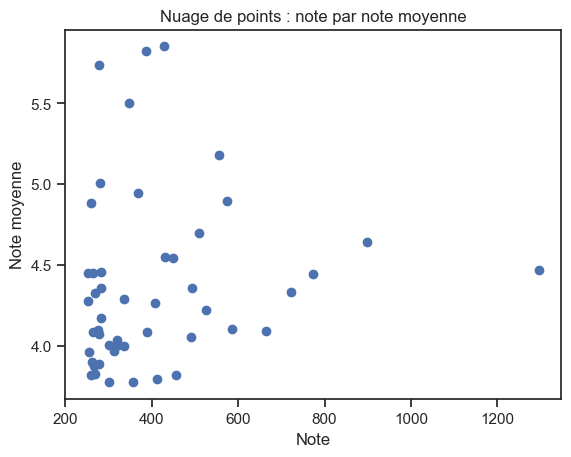

In [159]:
# Données du nombre d'évaluations et de la note moyenne
note = livre_evalue['Note']
note_moyenne = livre_evalue['Note-Moyenne']

# Création du nuage de points
plt.scatter(note, note_moyenne)

# Ajout des étiquettes aux axes
plt.xlabel('Note')
plt.ylabel('Note moyenne')
plt.title('Nuage de points : note par note moyenne')

# Affichage du nuage de points
plt.show()

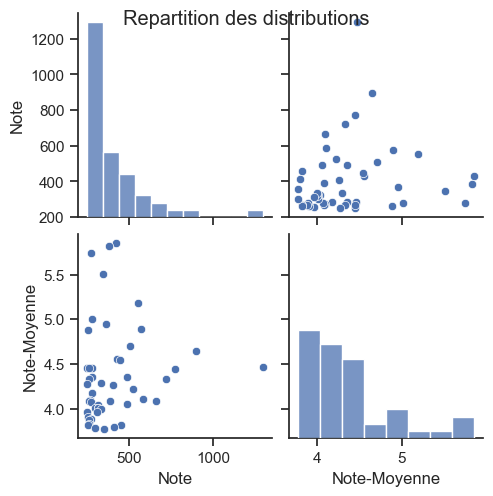

In [160]:
# Données du nombre d'évaluations et de la note moyenne
note = livre_evalue['Note']
note_moyenne = livre_evalue['Note-Moyenne']

# Création du DataFrame avec les données
data = pd.DataFrame({'Note': note, 'Note-Moyenne': note_moyenne})

# Calcul de la matrice de corrélation
correlation_matrix = data.corr()

# Création du nuage de points avec matrice de corrélation
sns.set(style="ticks", color_codes=True)
g = sns.pairplot(data)
g.fig.suptitle('Repartition des distributions')

# Affichage du nuage de points avec matrice de corrélation
plt.show()

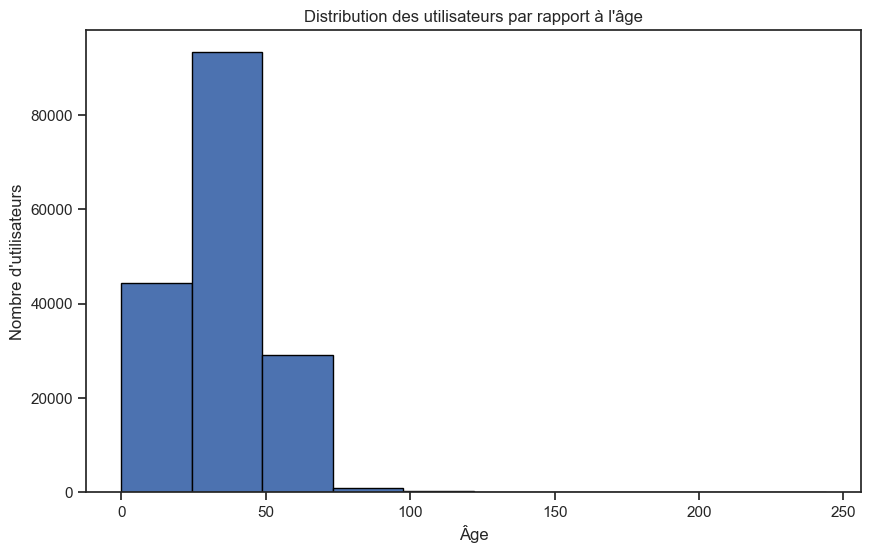

In [219]:
plt.figure(figsize=(10, 6))
plt.hist(users['Age'], bins=10, edgecolor='black')
plt.xlabel('Âge')
plt.ylabel('Nombre d\'utilisateurs')
plt.title('Distribution des utilisateurs par rapport à l\'âge')
plt.show()

## Implementation du Système de Recommandation basé sur le filtrage collaboratif

In [209]:
x = evaluation_livre.groupby('User-ID').count()['Titre'] > 200 # groupby pour regrouper les données de evaluation_livre en fonction de la colonne 'User-ID'. Ensuite, il compte le nombre d'occurrences de 'Titre' pour chaque groupe.Enfin, il vérifie si le compte pour chaque groupe est supérieur à 200, ce qui donne une série booléenne indiquant quels groupes satisfont cette condition.
table_true = x[x].index # La variable table_true représente les indices des groupes qui satisfont la condition x

In [210]:
note_filtre = evaluation_livre[evaluation_livre['User-ID'].isin(table_true)] # evaluation_livre contient uniquement les lignes où la colonne 'User-ID' appartient aux indices présents dans table_true

In [211]:
y = note_filtre.groupby('Titre').count()['Note']>=50 #  indique si chaque titre dans note_filtre a au moins 50 occurrences dans la colonne 'Note'
livre_celebre = y[y].index #contient les indices des titres qui satisfont la condition y

In [212]:
note_finale = note_filtre[note_filtre['Titre'].isin(livre_celebre)] # note_finale représente un sous-ensemble de note_filtre qui ne contient que les lignes où la colonne 'Titre' appartient aux indices présents dans livre_celebre

In [213]:
pivot = note_finale.pivot_table(index='Titre',columns='User-ID',values='Note') # crée une table pivot (pivot_table) à partir de note_finale.

In [214]:
pivot.fillna(0,inplace=True) # remplace les valeurs manquantes (NaN) dans la table pivot par des zéros. 

In [215]:
pivot

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Titre,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [216]:
similarity_scores = cosine_similarity(pivot) # Calcule les scores de similarité cosine entre les lignes de la table pivot. 

In [192]:
def recommend(book_name):
    # Extraction d'index
    index = np.where(pivot.index==book_name)[0][0] # Recherche l'indice de book_name dans l'index du tableau pivot.
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:11] # Sélectionne les 4 livres les plus similaires à book_name en utilisant les scores de similarité cosine. 
    
    data = [] # Liste vide
    for i in similar_items: # Cette boucle permet de faire des itérations sur les livres similaires sélectionnés
        item = []
        temp = books[books['Titre'] == pivot.index[i[0]]] # extrait les informations du livre similaire .
        item.extend(list(temp.drop_duplicates('Titre')['Titre'].values))
        item.extend(list(temp.drop_duplicates('Titre')['Auteur'].values))
        
        data.append(item) # Le contenu de la liste item est à la fin ajouter dans la liste data
    
    return data # à la fin de la boucle, on retourne data

In [185]:
livre_evalue

,Titre,Auteur,Note,Note-Moyenne
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,260,4.880769
39,To Kill a Mockingbird,Harper Lee,510,4.700000


In [220]:
recommend("Silence of the Lambs")

[['Red Dragon', 'Thomas Harris'],
 ['The Vampire Lestat (Vampire Chronicles, Book II)', 'ANNE RICE'],
 ['Wizard and Glass (The Dark Tower, Book 4)', 'Stephen King'],
 ['Desperation', 'Stephen King'],
 ['E Is for Evidence: A Kinsey Millhone Mystery (Kinsey Millhone Mysteries (Paperback))',
  'Sue Grafton'],
 ['Rules of Prey', 'John Sandford'],
 ['Red Storm Rising', 'Tom Clancy'],
 ['The Body Farm', 'Patricia Daniels Cornwell'],
 ['The Witching Hour (Lives of the Mayfair Witches)', 'ANNE RICE'],
 ['The Tommyknockers', 'Stephen King']]

## CONCLUSION

Un système de recommandation est un outil qui analyse les données sur les préférences des utilisateurs et les utilise pour suggérer des éléments pertinents.
Sa mise en œuvre peut varier en fonction de plusieurs facteurs, 
tels que le type de données disponibles, le contexte d'application et les objectifs spécifiques
du système de recommandation.